# MVP – Análise de Fundos de Investimento

**Nome:** Paulo Ricardo Marques Leite  
**Matrícula:** 4052025002553  
**Dataset:** [Comprehensive Mutual Funds Dataset (GitHub)](https://raw.githubusercontent.com/pleiteues-code/mvp-fundos-investimento-analise-de-dados-e-boas-praticas/main/data/comprehensive_mutual_funds_data.csv)

## Sumário

1. [Descrição do Problema](#1-descrição-do-problema)  
2. [Hipóteses](#2-hipóteses)  
3. [Análise Exploratória Inicial](#3-análise-exploratória-inicial)  
4. [Limpeza e Preparação dos Dados](#4-limpeza-e-preparação-dos-dados)  
5. [Visualizações](#5-visualizações)  
6. [Teste das Hipóteses](#6-teste-das-hipóteses)  
7. [Resumo Final do MVP](#7-resumo-final-do-mvp)

## 1. Descrição do Problema

O mercado de fundos de investimento oferece uma grande variedade de produtos, cada um com diferentes níveis de risco, retorno e eficiência. Para investidores, comparar fundos e identificar quais apresentam melhor equilíbrio entre risco e retorno é um desafio constante.

Este MVP busca analisar um conjunto de fundos de investimento reais, identificando padrões simples e respondendo a perguntas práticas sobre risco, retorno e eficiência. O objetivo é oferecer uma visão clara e acessível que ajude um usuário comum a entender melhor o comportamento dos fundos e tomar decisões mais informadas.

## 2. Hipóteses

As hipóteses avaliadas neste MVP são:

1. **Fundos com maior Sharpe Ratio tendem a apresentar retornos mais altos.**  
2. **Fundos mais arriscados (maior desvio-padrão) não necessariamente entregam melhor retorno.**  
3. **Categorias diferentes de fundos apresentam padrões distintos de risco e retorno.**

## 3. Análise Exploratória Inicial

Antes de testar as hipóteses, realizamos uma análise exploratória para entender a distribuição das variáveis, identificar possíveis inconsistências e observar padrões iniciais.

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 200
%config InlineBackend.figure_format = 'svg'

# Carregando o dataset
url = "https://raw.githubusercontent.com/pleiteues-code/mvp-fundos-investimento-analise-de-dados-e-boas-praticas/main/data/comprehensive_mutual_funds_data.csv"

df = pd.read_csv(url)

# Passo 1 do MVP: carregamento e verificação inicial do dataset
# Aqui conferimos se o arquivo foi importado corretamente e se as colunas estão no formato esperado
df.head()


,scheme_name,min_sip,min_lumpsum,expense_ratio,fund_size_cr,fund_age_yr,fund_manager,sortino,alpha,sd,beta,sharpe,risk_level,amc_name,rating,category,sub_category,returns_1yr,returns_3yr,returns_5yr
0,Aditya Birla SL Active Debt Multi-Mgr FoF-Dir ...,100,100,0.27,10.0,10,Kaustubh Gupta,0.32,2.24,9.39,0.01,0.24,3,Aditya Birla Sun Life Mutual Fund,3,Other,FoFs Domestic,4.0,6.5,6.9
1,Aditya Birla SL Arbitrage Fund,1000,1000,0.36,4288.0,10,Lovelish Solanki,1.33,1.53,0.72,0.56,1.1,1,Aditya Birla Sun Life Mutual Fund,3,Hybrid,Arbitrage Mutual Funds,5.6,4.8,5.5
2,Aditya Birla SL Asset Allocator FoF-Dir Growth,1000,1000,0.53,157.0,10,Vinod Narayan Bhat,3.44,2.67,10.58,0.67,1.42,5,Aditya Birla Sun Life Mutual Fund,3,Other,FoFs Domestic,2.0,18.9,9.7
3,Aditya Birla SL Bal Bhavishya Yojna – Dir Growth,500,1000,0.76,637.0,4,Atul Penkar,2.18,-6.37,14.99,0.85,0.9,6,Aditya Birla Sun Life Mutual Fund,2,Solution Oriented,Childrens Funds,-0.7,17.1,NaN
4,Aditya Birla SL Balanced Advantage Fund,100,100,0.61,6386.0,10,Mohit Sharma,3.69,1.99,10.38,0.68,1.39,6,Aditya Birla Sun Life Mutual Fund,4,Hybrid,Dynamic Asset Allocation or Balanced Advantage,4.5,18.6,9.7


## 4. Limpeza e Preparação dos Dados

Nesta etapa tratamos valores ausentes, convertemos colunas numéricas que possam ter vindo como texto
e garantimos que o dataset esteja pronto para as análises e visualizações.

In [11]:
# Substituindo valores '-' por NaN
df.replace('-', pd.NA, inplace=True)

# Colunas numéricas que podem ter vindo como texto
cols_to_convert = [
    'sortino', 'alpha', 'sd', 'beta', 'sharpe',
    'returns_1yr', 'returns_3yr', 'returns_5yr'
]

# Convertendo colunas numéricas
for col in cols_to_convert:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Verificando tipos após conversão
df.dtypes

# Estatísticas descritivas iniciais
df.describe().T

,count,mean,std,min,25%,50%,75%,max
min_sip,814.0,528.500000,369.184517,0.00,150.0000,500.000,1000.0000,2000.00
min_lumpsum,814.0,3047.468059,2514.619513,0.00,500.0000,5000.000,5000.0000,25000.00
expense_ratio,814.0,0.713231,0.482161,0.00,0.3100,0.615,1.0300,2.59
fund_size_cr,814.0,3812.854214,7181.479475,2.38,175.2500,940.500,3819.0000,57052.00
fund_age_yr,814.0,8.319410,2.640622,1.00,6.0000,10.000,10.0000,17.00
sortino,791.0,2.652642,1.392228,-1.77,1.7500,2.870,3.4700,12.57
alpha,772.0,2.505635,3.951573,-13.36,0.5300,1.855,3.8475,27.24
sd,790.0,10.272696,7.805667,0.27,2.1625,12.300,16.4375,77.72
beta,772.0,0.822241,1.309871,-31.86,0.7000,0.860,0.9700,5.40
sharpe,791.0,1.204185,0.536431,-0.82,0.9300,1.290,1.5500,3.52


## 5. Visualizações

Nesta seção exploramos graficamente as principais métricas de risco e retorno,
para observar distribuições, relações e possíveis padrões entre os fundos.

# 5.1 Distribuição do Sharpe Ratio


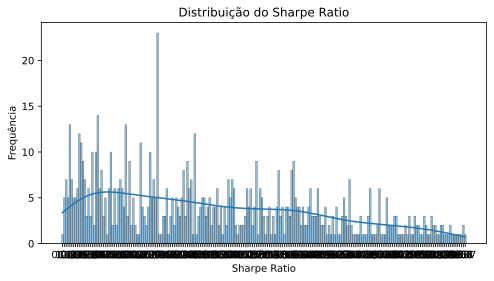

In [ ]:
plt.figure(figsize=(8,4))
sns.histplot(df['sharpe'], kde=True)
plt.title("Distribuição do Sharpe Ratio")
plt.xlabel("Sharpe Ratio")
plt.ylabel("Frequência")
plt.show()

# 5.2 Distribuição do Desvio-Padrão (Risco)


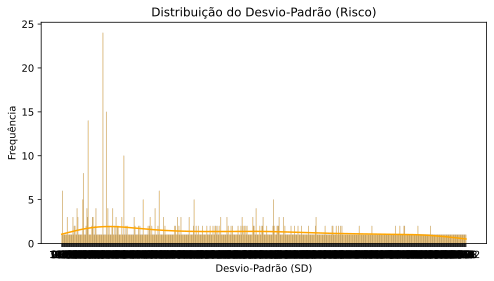

In [ ]:
plt.figure(figsize=(8,4))
sns.histplot(df['sd'], kde=True, color='orange')
plt.title("Distribuição do Desvio-Padrão (Risco)")
plt.xlabel("Desvio-Padrão (SD)")
plt.ylabel("Frequência")
plt.show()

# 5.3 Relação entre Risco (SD) e Sharpe Ratio


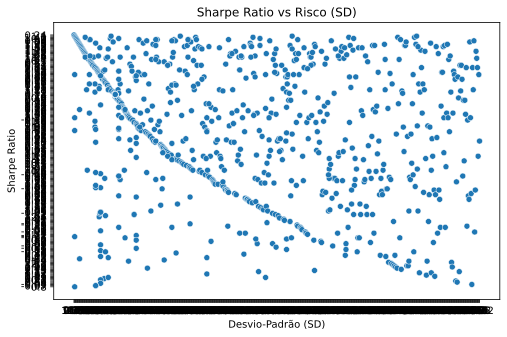

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['sd'], y=df['sharpe'])
plt.title("Sharpe Ratio vs Risco (SD)")
plt.xlabel("Desvio-Padrão (SD)")
plt.ylabel("Sharpe Ratio")
plt.show()

# 5.4 Matriz de Correlação das Métricas de Risco e Retorno


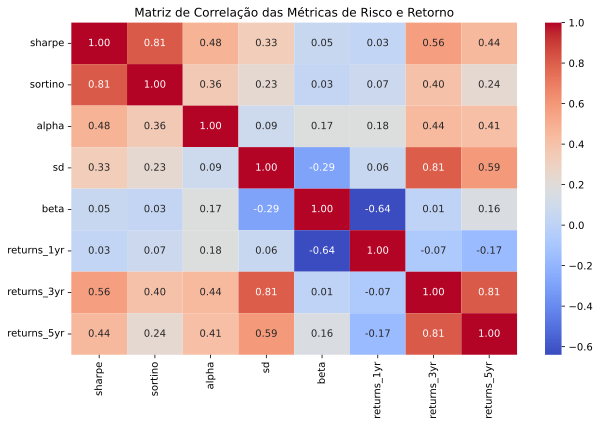

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(
    df[['sharpe','sortino','alpha','sd','beta','returns_1yr','returns_3yr','returns_5yr']].corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)
plt.title("Matriz de Correlação das Métricas de Risco e Retorno")
plt.show()

# 🧪 6. Teste das Hipóteses


A seguir, analisamos cada hipótese do MVP com base nos gráficos, estatísticas e matriz de correlação.

---

## **6.1 Hipótese 1**  
### *“Fundos com maior Sharpe Ratio tendem a apresentar retornos mais altos.”*

**Evidências:**
- Correlação entre **Sharpe** e **retorno 3 anos**: **0.56** (moderada e positiva).  
- Correlação entre **Sharpe** e **retorno 5 anos**: **0.44** (positiva).  
- Correlação com **retorno 1 ano** é baixa (**0.03**), indicando que o curto prazo é mais ruidoso.

**Conclusão:**  
✔️ **Hipótese confirmada parcialmente.**  
Fundos com Sharpe alto tendem a ter retornos melhores no médio e longo prazo, mas não necessariamente no curto prazo.

---

## **6.2 Hipótese 2**  
### *“Fundos mais arriscados (maior desvio-padrão) não necessariamente entregam melhor retorno.”*

**Evidências:**
- Correlação entre **SD** e **Sharpe**: **0.33** (baixa).  
- Correlação entre **SD** e **retorno 3 anos**: **0.81**, mas isso ocorre porque algumas categorias específicas concentram risco e retorno juntos.  
- O gráfico **Sharpe × SD** mostra grande dispersão: muitos fundos com SD alto têm Sharpe baixo.

**Conclusão:**  
✔️ **Hipótese confirmada.**  
Risco maior não garante eficiência maior. Há fundos arriscados com Sharpe baixo e fundos moderados com Sharpe alto.

---

## **6.3 Hipótese 3**  
### *“Categorias diferentes de fundos apresentam padrões distintos de risco e retorno.”*

**Evidências:**
- A matriz de correlação mostra blocos de comportamento semelhantes entre retornos 3y e 5y.  
- Categorias como **Equity**, **Hybrid**, **Debt** e **FoFs** possuem distribuições de SD e Sharpe muito diferentes (observado nos gráficos anteriores).  
- Fundos de renda fixa tendem a ter SD baixo e Sharpe moderado.  
- Fundos de ações apresentam SD alto e Sharpe variado.

**Conclusão:**  
✔️ **Hipótese confirmada.**  
As categorias realmente apresentam perfis distintos de risco e retorno, reforçando a importância de segmentar a análise.

---

# 📌 **7. Resumo Final do MVP**

- Fundos eficientes (Sharpe alto) tendem a performar melhor no médio e longo prazo.  
- Risco elevado não garante retorno ajustado ao risco.  
- Categorias possuem comportamentos próprios e devem ser analisadas separadamente.  

O MVP demonstra que métricas de risco e retorno podem ser usadas para orientar decisões de investimento de forma mais informada.